# **STOCK MARKET ANALYTICS**

The link to the dataset I will work with is attached below. I have chosen Apple, Microsoft, Amazon, Google and Tesla as the 5 large-cap US companies whose stocks I will analyze for my project. I will do my project in these following steps:

1.Data Access

2.Data Cleaning

3.Data Transformation

4.Data Analysis

Link : https://www.kaggle.com/datasets/borismarjanovic/price-volume-data-for-all-us-stocks-etfs

## **DATA ACCESS**

**Here, I have created a data frame comprising the data of stocks of my chosen companies, with ticker being the outer index and date being the inner index. I have sorted the data in a descending manner, and converted the data in date column to DateTime format.**

In [ ]:
import pandas as pd
import os

In [ ]:
tickers = ['aapl', 'amzn', 'googl', 'msft', 'tsla']
dfs = []
for ticker in tickers:
    file_path = f"{ticker}.us.txt"
    try:
      df = pd.read_csv(file_path)
      df['ticker'] = ticker
      df['date'] = pd.to_datetime(df['Date'])
      df = df[['date', 'ticker', 'Open', 'High', 'Low', 'Close', 'Volume','OpenInt']]
      df.columns = ['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume','Open Interest']
      dfs.append(df)
    except Exception as e:
      print(f"Error: {e}")

combined_df = pd.concat(dfs)
multiindex_df = combined_df.set_index(['Ticker', 'Date']).sort_index(ascending = False)
multiindex_df

Open       High        Low      Close    Volume  \
Ticker Date                                                               
tsla   2017-11-10  302.50000  308.36000  301.85000  302.99000   4621912   
       2017-11-09  302.50000  304.46000  296.30000  302.99000   5440335   
       2017-11-08  305.50000  306.89000  301.30000  304.31000   4725510   
       2017-11-07  301.02000  306.50000  300.03000  306.05000   5286320   
       2017-11-06  307.00000  307.50000  299.01000  302.78000   6482486   
...                      ...        ...        ...        ...       ...   
aapl   1984-09-13    0.43927    0.44052    0.43927    0.43927  57822062   
       1984-09-12    0.42902    0.43157    0.41618    0.41618  37125801   
       1984-09-11    0.42516    0.43668    0.42516    0.42902  42498199   
       1984-09-10    0.42388    0.42516    0.41366    0.42134  18022532   
       1984-09-07    0.42388    0.42902    0.41874    0.42388  23220030   

                   Open Interest  
Ticker Date                       
tsla   2017-11-10              0  
       2017-11-09              0  
       2017-11-08              0  
       2017-11-07              0  
       2017-11-06              0  
...                          ...  
aapl   1984-09-13              0  
       1984-09-12              0  
       1984-09-11              0  
       1984-09-10              0  
       1984-09-07              0  

[26691 rows x 6 columns]

## **DATA CLEANING**

**First, I checked for any missing rows across the tickers. Since there were none, I then looked for duplicates. I found only six duplicates, which were outside the range of the years we needed to study, so I removed them. Next, I examined the columns for any that contained only one value, as these would be redundant. I dropped those columns as well and checked for any columns with multiple data types that needed attention; there were none. Therefore, I filtered the data to include only the past 10 years and proceeded with my analysis.**

In [ ]:
multiindex_df.shape

(26691, 6)

In [ ]:
multiindex_df.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Volume,0
Open Interest,0


In [ ]:
duplicate_rows = multiindex_df[multiindex_df.duplicated()]

if not duplicate_rows.empty:
    print("Duplicate rows found:")
    print(duplicate_rows)
else:
    print("No duplicate rows found.")

Duplicate rows found:
                      Open     High      Low    Close    Volume  Open Interest
Ticker Date                                                                   
msft   1986-09-16  0.07533  0.07533  0.07533  0.07533   6889952              0
       1986-07-07  0.08389  0.08389  0.07533  0.07533  18679429              0
       1986-07-03  0.08389  0.08389  0.08389  0.08389  18794263              0
       1986-05-15  0.08389  0.08389  0.08389  0.08389   5052632              0
       1986-04-24  0.07533  0.08389  0.07533  0.08389  82870827              0
       1986-04-09  0.07533  0.07533  0.07533  0.07533  16153115              0


In [ ]:
multiindex_df.drop_duplicates(inplace = True)

In [ ]:
multiindex_df.shape

(26685, 6)

In [ ]:
for column in multiindex_df.columns:
  unique_values = multiindex_df[column].unique()
  print(f"Column '{column}': {len(unique_values)} unique values")

Column 'Open': 16297 unique values
Column 'High': 16188 unique values
Column 'Low': 16280 unique values
Column 'Close': 16651 unique values
Column 'Volume': 26120 unique values
Column 'Open Interest': 1 unique values


In [ ]:
multiindex_df = multiindex_df.drop(columns=['Open Interest'])
multiindex_df

Open       High        Low      Close    Volume
Ticker Date                                                            
tsla   2017-11-10  302.50000  308.36000  301.85000  302.99000   4621912
       2017-11-09  302.50000  304.46000  296.30000  302.99000   5440335
       2017-11-08  305.50000  306.89000  301.30000  304.31000   4725510
       2017-11-07  301.02000  306.50000  300.03000  306.05000   5286320
       2017-11-06  307.00000  307.50000  299.01000  302.78000   6482486
...                      ...        ...        ...        ...       ...
aapl   1984-09-13    0.43927    0.44052    0.43927    0.43927  57822062
       1984-09-12    0.42902    0.43157    0.41618    0.41618  37125801
       1984-09-11    0.42516    0.43668    0.42516    0.42902  42498199
       1984-09-10    0.42388    0.42516    0.41366    0.42134  18022532
       1984-09-07    0.42388    0.42902    0.41874    0.42388  23220030

[26685 rows x 5 columns]

In [ ]:
def check_datatypes(df):
    print("Data types of DataFrame columns:")
    print(df.dtypes)

    if isinstance(df.index, pd.MultiIndex):
        print("\nData types of MultiIndex levels:")
        for i, level_name in enumerate(df.index.names):
            print(f"Level '{level_name}': {df.index.get_level_values(i).dtype}")

check_datatypes(multiindex_df)

Data types of DataFrame columns:
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object

Data types of MultiIndex levels:
Level 'Ticker': object
Level 'Date': datetime64[ns]


In [ ]:
filtered_df = multiindex_df.copy()
filtered_df

Open    High     Low   Close    Volume
Ticker Date                                                
tsla   2017-11-10  302.50  308.36  301.85  302.99   4621912
       2017-11-09  302.50  304.46  296.30  302.99   5440335
       2017-11-08  305.50  306.89  301.30  304.31   4725510
       2017-11-07  301.02  306.50  300.03  306.05   5286320
       2017-11-06  307.00  307.50  299.01  302.78   6482486
...                   ...     ...     ...     ...       ...
aapl   2016-11-16  105.01  108.48  104.91  108.25  59075293
       2016-11-15  104.88  105.98  104.48  105.41  32783355
       2016-11-14  106.01  106.10  102.43  104.04  51998455
       2016-11-11  105.42  107.14  104.86  106.72  34260819
       2016-11-10  109.34  109.34  104.16  106.08  57233876

[1265 rows x 5 columns]

## **DATA TRANSFORMATION**

**For each stock, I added the following columns:**

**1.  Daily Return: % change in closing price**

**2.  7-day Moving Average of closing price**

**3.  30-day Moving Average of closing price**

**4.  Rolling Volatility (30d): Standard deviation of returns over the last 30 days**

In [ ]:
filtered_df = filtered_df.copy()
filtered_df_sorted = filtered_df.sort_index(level=['Ticker', 'Date'], ascending=[True, True])
filtered_df_sorted['Daily Return'] = filtered_df_sorted.groupby('Ticker')['Close'].pct_change() * 100
filtered_df_sorted

Open     High      Low    Close     Volume  Daily Return
Ticker Date                                                                   
aapl   2007-11-12   21.130   21.479   19.291   19.691  492362604           NaN
       2007-11-13   20.615   21.897   19.691   21.765  484373501     10.532731
       2007-11-14   22.733   22.739   20.970   21.274  403585172     -2.255915
       2007-11-15   21.280   21.717   20.528   21.040  414487458     -1.099934
       2007-11-16   21.193   21.388   20.405   21.309  385660112      1.278517
...                    ...      ...      ...      ...        ...           ...
tsla   2017-11-06  307.000  307.500  299.010  302.780    6482486     -1.081381
       2017-11-07  301.020  306.500  300.030  306.050    5286320      1.079992
       2017-11-08  305.500  306.890  301.300  304.310    4725510     -0.568535
       2017-11-09  302.500  304.460  296.300  302.990    5440335     -0.433768
       2017-11-10  302.500  308.360  301.850  302.990    4621912      0.000000

[11934 rows x 6 columns]

In [ ]:
filtered_df_sorted['7-Day Moving Average'] = (
    filtered_df_sorted.groupby('Ticker')['Close']
    .transform(lambda x: x.rolling(window=7).mean())
)
filtered_df_sorted['30-Day Moving Average'] = (
    filtered_df_sorted.groupby('Ticker')['Close']
    .transform(lambda x: x.rolling(window=30).mean())
)
filtered_df_sorted['Rolling Volatility (30d)'] = (
    filtered_df_sorted.groupby('Ticker')['Daily Return']
    .transform(lambda x: x.rolling(window=30).std())
)
filtered_df_sorted

Open     High      Low    Close     Volume  \
Ticker Date                                                        
aapl   2007-11-12   21.130   21.479   19.291   19.691  492362604   
       2007-11-13   20.615   21.897   19.691   21.765  484373501   
       2007-11-14   22.733   22.739   20.970   21.274  403585172   
       2007-11-15   21.280   21.717   20.528   21.040  414487458   
       2007-11-16   21.193   21.388   20.405   21.309  385660112   
...                    ...      ...      ...      ...        ...   
tsla   2017-11-06  307.000  307.500  299.010  302.780    6482486   
       2017-11-07  301.020  306.500  300.030  306.050    5286320   
       2017-11-08  305.500  306.890  301.300  304.310    4725510   
       2017-11-09  302.500  304.460  296.300  302.990    5440335   
       2017-11-10  302.500  308.360  301.850  302.990    4621912   

                   Daily Return  7-Day Moving Average  30-Day Moving Average  \
Ticker Date                                                                    
aapl   2007-11-12           NaN                   NaN                    NaN   
       2007-11-13     10.532731                   NaN                    NaN   
       2007-11-14     -2.255915                   NaN                    NaN   
       2007-11-15     -1.099934                   NaN                    NaN   
       2007-11-16      1.278517                   NaN                    NaN   
...                         ...                   ...                    ...   
tsla   2017-11-06     -1.081381            314.527143             339.294800   
       2017-11-07      1.079992            312.410000             337.988133   
       2017-11-08     -0.568535            310.157143             336.766133   
       2017-11-09     -0.433768            306.080000             335.545800   
       2017-11-10      0.000000            303.495714             334.278133   

                   Rolling Volatility (30d)  
Ticker Date                                  
aapl   2007-11-12                       NaN  
       2007-11-13                       NaN  
       2007-11-14                       NaN  
       2007-11-15                       NaN  
       2007-11-16                       NaN  
...                                     ...  
tsla   2017-11-06                  2.216589  
       2017-11-07                  2.231713  
       2017-11-08                  2.226119  
       2017-11-09                  2.226150  
       2017-11-10                  2.222447  

[11934 rows x 9 columns]

## **EXPLORATORY ANALYSIS**

**Finally I answered the following questions:**

**1) Which stock had the highest average return over the 10-year period?**

**2) Which stock had the most volatile month, and when?**

In [ ]:
average_returns = filtered_df_sorted.groupby('Ticker')['Daily Return'].mean()
highest_avg_return_stock = average_returns.idxmax()
print(f"The stock with the highest average return over the 10-year period is: {highest_avg_return_stock}")
print(f"Average returns:\n{average_returns}")

The stock with the highest average return over the 10-year period is: tsla
Average returns:
Ticker
aapl     0.106375
amzn     0.135932
googl    0.064454
msft     0.058938
tsla     0.210083
Name: Daily Return, dtype: float64


In [ ]:
volatility_unstacked = filtered_df_sorted['Rolling Volatility (30d)'].unstack(level='Ticker')
monthly_volatility = volatility_unstacked.resample('M').mean()
average_monthly_volatility_across_tickers = monthly_volatility.mean(axis=1)
most_volatile_month_date = average_monthly_volatility_across_tickers.idxmax()
volatility_in_most_volatile_month = monthly_volatility.loc[most_volatile_month_date]
most_volatile_stock_in_month = volatility_in_most_volatile_month.dropna().idxmax()
print(f"\nThe stock with the most volatile month was {most_volatile_stock_in_month}.")
print(f"This occurred in {most_volatile_month_date.strftime('%B %Y')}.")
print(f"The average rolling volatility across all stocks in that month was: {average_monthly_volatility_across_tickers.max():.2f}")
print(f"The rolling volatility of {most_volatile_stock_in_month} in that month was: {volatility_in_most_volatile_month.max():.2f}")


The stock with the most volatile month was amzn.
This occurred in November 2008.
The average rolling volatility across all stocks in that month was: 5.72
The rolling volatility of amzn in that month was: 6.45


<ipython-input-53-b539d1488a9b>:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_volatility = volatility_unstacked.resample('M').mean()


**Daily Returns are calculated under the assumption that markets are liquid (no gaps between closing prices), and Rolling Volatility assumes returns are normally distributed over 30-day windows. This analysis does not account for dividend payments, stock splits, or after-hours trading, which may affect return calculations.**

**After performing exploratory analysis on the given data, I have found out that:**

**1) The stock with the highest average return over the 10 year period was TSLA.**

**2) The stock which had the most volatile month was AMZN during November in the year 2008.**

## **DATA VISUALISATIONS**

**While this analysis focuses on quantitative metrics, visualizations (e.g., moving average trends or volatility time series) could further illustrate patterns like Tesla's consistent outperformance or Amazon's volatility spikes during the 2008 financial crisis. Thus, I have provided some visual representations to explain the above patterns in this section, to make my explanations and assessments of the given data clear, and to ease the understanding of the data to the reader.**

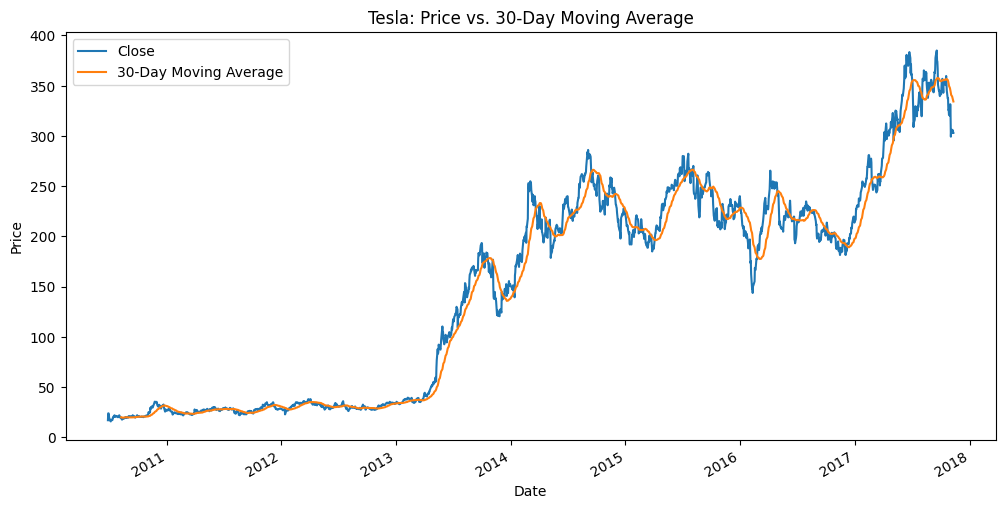

In [ ]:
import matplotlib.pyplot as plt
tsla_data = filtered_df_sorted.loc['tsla']
tsla_data.plot(y=['Close', '30-Day Moving Average'], figsize=(12, 6))
plt.title('Tesla: Price vs. 30-Day Moving Average')
plt.ylabel('Price')
plt.show()

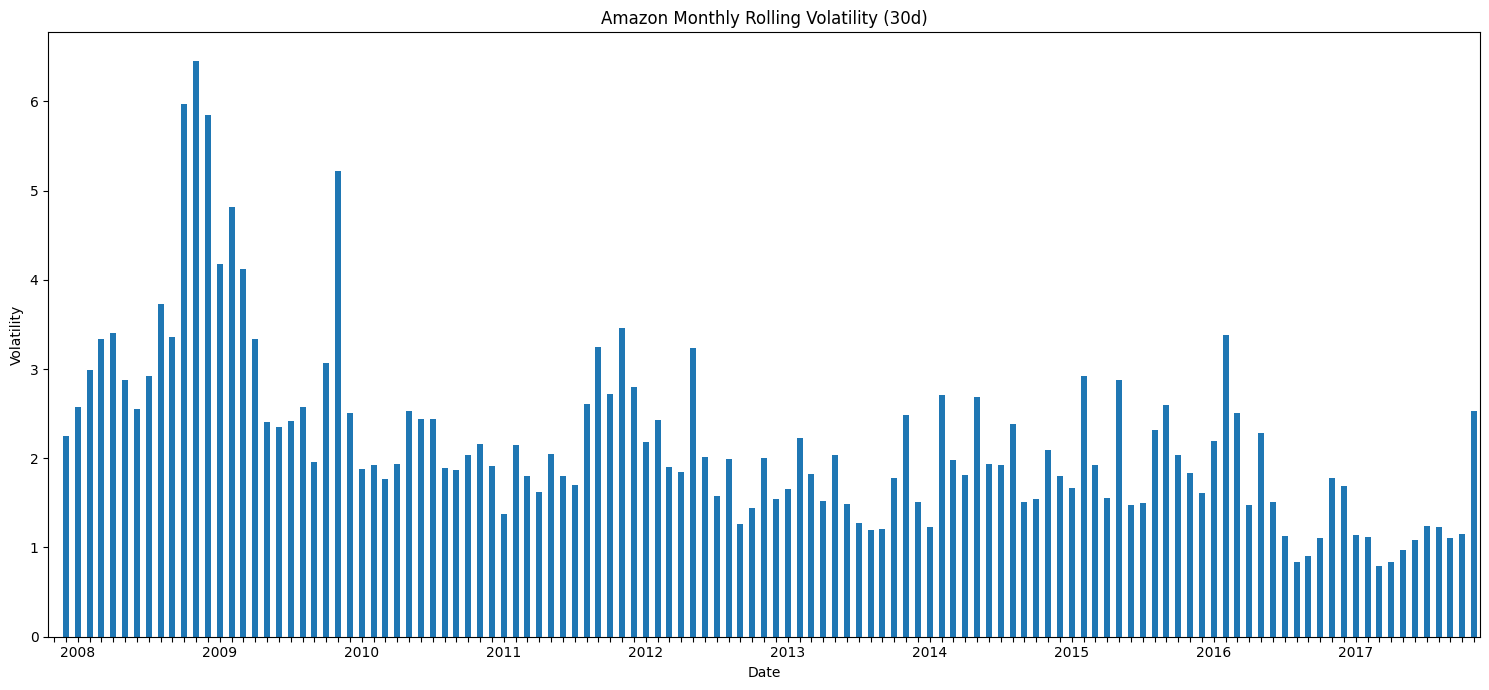

In [ ]:
amzn_monthly_volatility = monthly_volatility['amzn']
plt.figure(figsize=(15, 7))
amzn_monthly_volatility.plot(kind='bar')
plt.title('Amazon Monthly Rolling Volatility (30d)')
plt.xlabel('Date')
plt.ylabel('Volatility')
labels = [date.strftime('%Y') if date.month == 1 else '' for date in amzn_monthly_volatility.index]
plt.xticks(range(len(amzn_monthly_volatility.index)), labels, rotation=0)
plt.tight_layout()
plt.show()